# Exploratory Data Analysis: Flight Delay Patterns

**Goal**: Extract actionable insights about when, where, and why flight delays occur.  
**Data**: Cleaned output from `data_preprocessing.ipynb` — reads `dataset/cleaned_flight_data.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

In [2]:
df = pd.read_csv('dataset/cleaned_flight_data.csv')
print(f'Shape: {df.shape}')
print(f'Year range: {int(df.year.min())} – {int(df.year.max())}')
print(f'Unique airports: {df.airport.nunique()}, Unique carriers: {df.carrier.nunique()}')
df.head(3)

Shape: (135293, 34)
Year range: 2020 – 2025
Unique airports: 391, Unique carriers: 25


,year,month,carrier,airline,airport,airport_full_name,total_flights,delayed_flights,carrier_delay_count,weather_delay_count,...,avg_delay_per_delayed_flight,season,quarter,is_high_delay,carrier_delay_pct,weather_delay_pct,nas_delay_pct,security_delay_pct,late_aircraft_delay_pct,dominant_delay_cause
0,2025,12,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",90.0,29.0,15.33,0.09,...,69.068966,Winter,4,1,51.123315,0.599101,9.585622,0.0,38.691962,carrier
1,2025,12,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",44.0,14.0,5.89,1.80,...,87.357143,Winter,4,1,40.147179,11.120196,1.062960,0.0,47.669665,late_aircraft
2,2025,12,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",81.0,26.0,7.35,0.73,...,83.153846,Winter,4,1,27.197040,1.526364,9.481961,0.0,61.794635,late_aircraft


## Overall Delay Landscape
What fraction of flights are delayed, cancelled, or diverted across the entire dataset?

In [3]:
total_flights = df['total_flights'].sum()
total_delayed = df['delayed_flights'].sum()
total_cancelled = df['cancelled_flights'].sum()
total_diverted = df['diverted_flights'].sum()

summary = pd.DataFrame({
    'Metric': ['Total Flights', 'Delayed (>15 min)', 'Cancelled', 'Diverted'],
    'Count': [total_flights, total_delayed, total_cancelled, total_diverted],
    'Percentage': [100, total_delayed/total_flights*100, total_cancelled/total_flights*100, total_diverted/total_flights*100]
})
summary['Percentage'] = summary['Percentage'].round(2)
summary

,Metric,Count,Percentage
0,Total Flights,40910253.0,100.00
1,Delayed (>15 min),7644272.0,18.69
2,Cancelled,917084.0,2.24
3,Diverted,97790.0,0.24



## Delay Trends Over Time
How has the delay rate evolved year-over-year and month-over-month? Are delays getting worse or better?

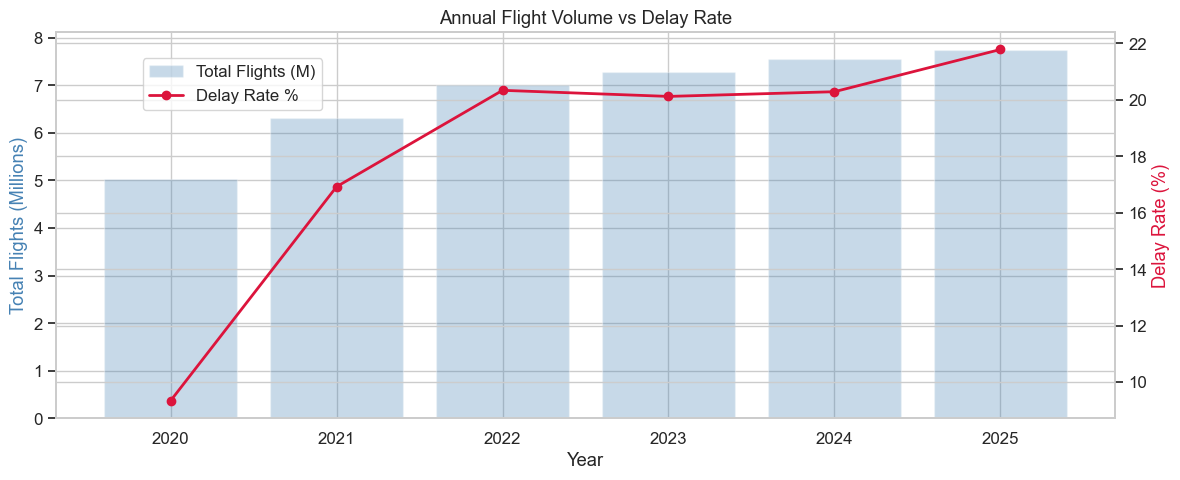

In [4]:
# Yearly trend
yearly = df.groupby('year').agg(
    total_flights=('total_flights', 'sum'),
    delayed_flights=('delayed_flights', 'sum')
).reset_index()
yearly['delay_rate'] = yearly['delayed_flights'] / yearly['total_flights']

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.bar(yearly['year'], yearly['total_flights']/1e6, alpha=0.3, color='steelblue', label='Total Flights (M)')
ax2.plot(yearly['year'], yearly['delay_rate']*100, color='crimson', marker='o', linewidth=2, label='Delay Rate %')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Flights (Millions)', color='steelblue')
ax2.set_ylabel('Delay Rate (%)', color='crimson')
ax1.set_title('Annual Flight Volume vs Delay Rate')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()

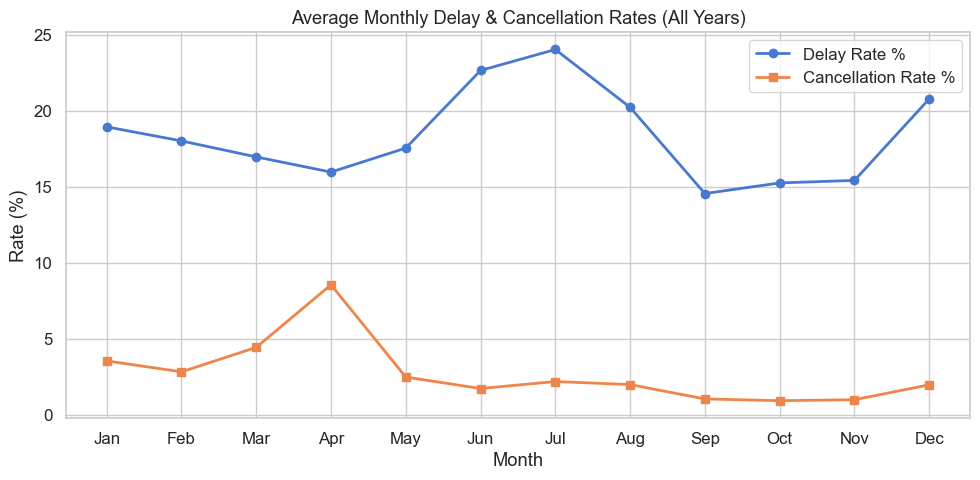

Worst month for delays: 7
Best month for delays: 9


In [5]:
# Monthly seasonality pattern (averaged across all years)
monthly_avg = df.groupby('month').agg(
    avg_delay_rate=('delay_rate', 'mean'),
    avg_cancel_rate=('cancellation_rate', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly_avg['month'], monthly_avg['avg_delay_rate']*100, marker='o', linewidth=2, label='Delay Rate %')
ax.plot(monthly_avg['month'], monthly_avg['avg_cancel_rate']*100, marker='s', linewidth=2, label='Cancellation Rate %')
ax.set_xticks(range(1,13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_xlabel('Month')
ax.set_ylabel('Rate (%)')
ax.set_title('Average Monthly Delay & Cancellation Rates (All Years)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Worst month for delays: {monthly_avg.loc[monthly_avg.avg_delay_rate.idxmax(), "month"]:.0f}')
print(f'Best month for delays: {monthly_avg.loc[monthly_avg.avg_delay_rate.idxmin(), "month"]:.0f}')

## Seasonal Impact Analysis
Which season causes the most disruption, and does the *type* of delay shift by season?

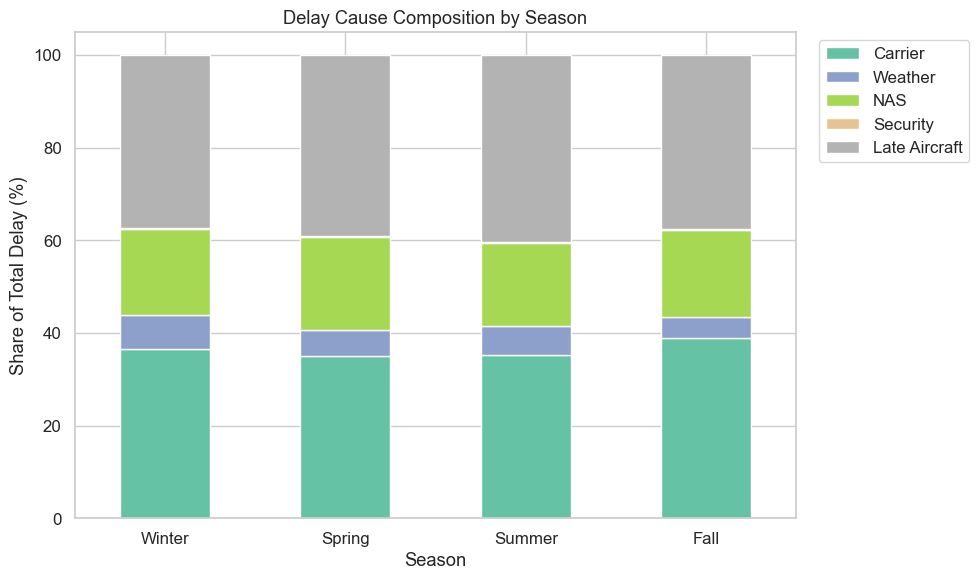


Key insight: Weather delay share by season:
  Winter: 7.4%
  Spring: 5.6%
  Summer: 6.4%
  Fall: 4.5%


In [6]:
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
delay_cols = ['carrier_delay_minutes', 'weather_delay_minutes', 'nas_delay_minutes',
              'security_delay_minutes', 'late_aircraft_delay_minutes']

season_causes = df.groupby('season')[delay_cols].sum()
season_causes = season_causes.loc[season_order]

# Normalize to percentages
season_pct = season_causes.div(season_causes.sum(axis=1), axis=0) * 100
season_pct.columns = ['Carrier', 'Weather', 'NAS', 'Security', 'Late Aircraft']

season_pct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2')
plt.title('Delay Cause Composition by Season')
plt.ylabel('Share of Total Delay (%)')
plt.xlabel('Season')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('\nKey insight: Weather delay share by season:')
for s in season_order:
    print(f'  {s}: {season_pct.loc[s, "Weather"]:.1f}%')


## Root Cause Breakdown
What are the primary drivers of delay across the entire dataset? How much delay time does each cause contribute?

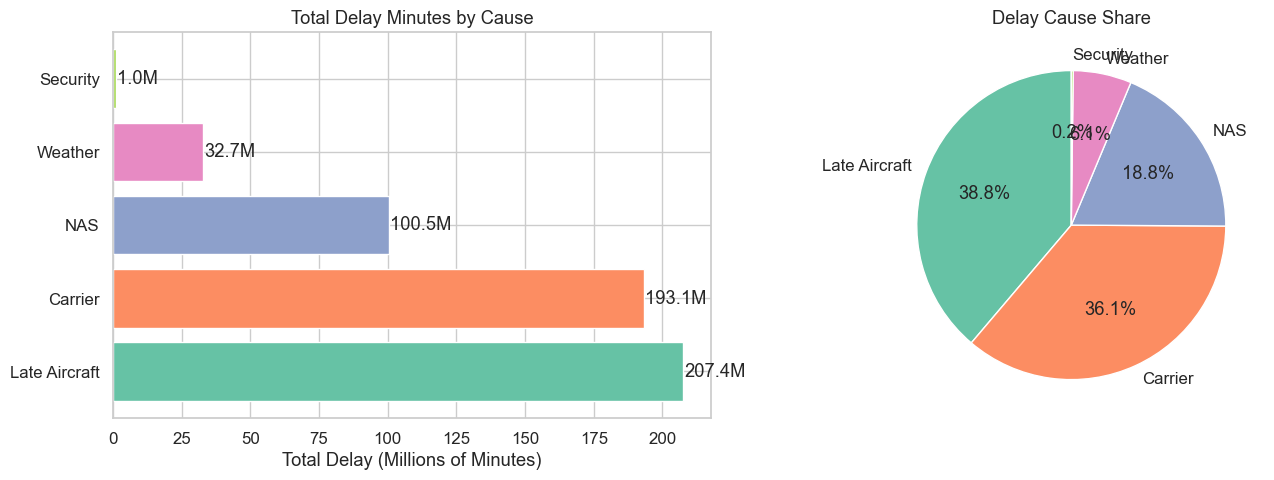

In [7]:
cause_totals = df[delay_cols].sum().sort_values(ascending=False)
cause_totals.index = ['Late Aircraft', 'Carrier', 'NAS', 'Weather', 'Security']
cause_pct = (cause_totals / cause_totals.sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart - absolute minutes
axes[0].barh(cause_totals.index, cause_totals.values / 1e6, color=sns.color_palette('Set2', 5))
axes[0].set_xlabel('Total Delay (Millions of Minutes)')
axes[0].set_title('Total Delay Minutes by Cause')
for i, v in enumerate(cause_totals.values):
    axes[0].text(v/1e6 + 0.5, i, f'{v/1e6:.1f}M', va='center')

# Pie chart - share
axes[1].pie(cause_pct, labels=cause_pct.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2', 5))
axes[1].set_title('Delay Cause Share')

plt.tight_layout()
plt.show()

## Airline Performance Comparison
Which airlines have the highest/lowest delay rates? How do delay severity and volume compare?

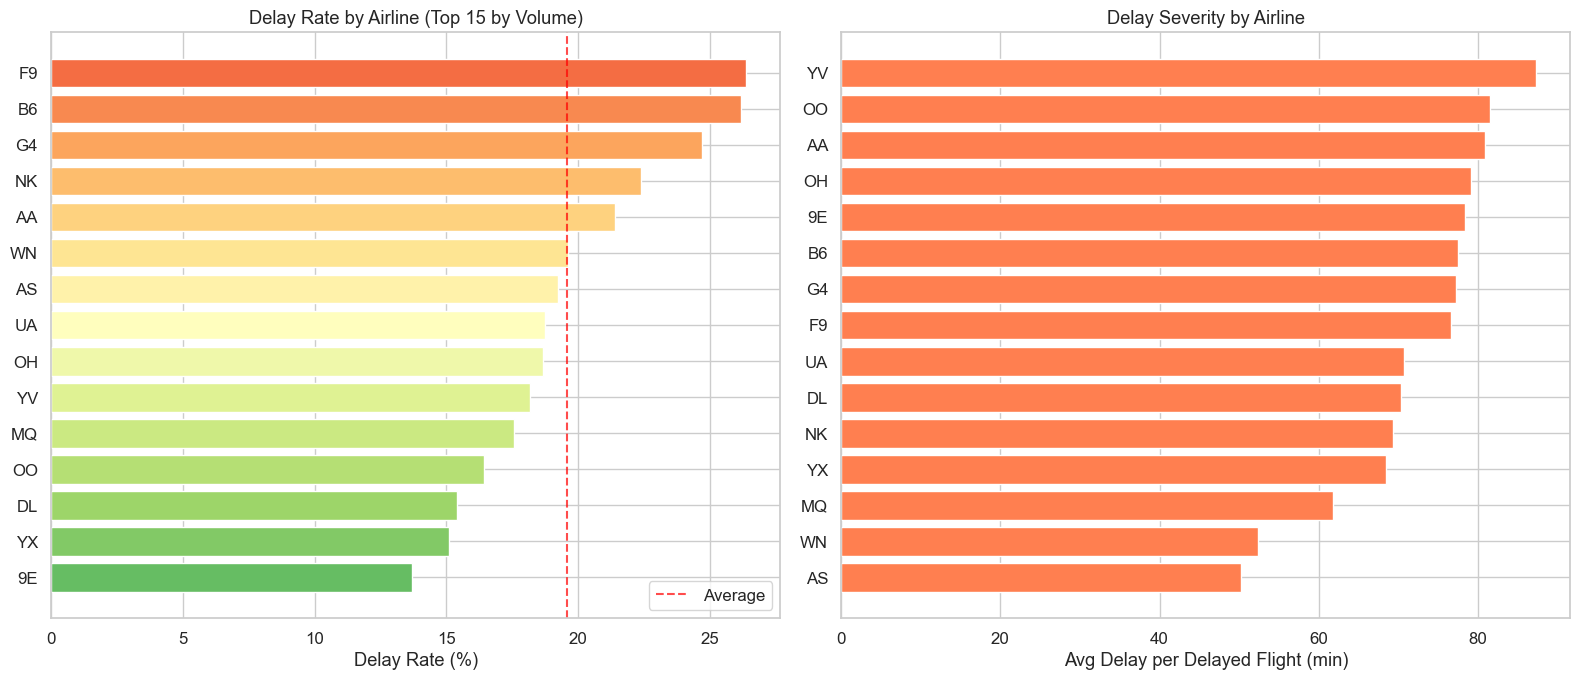


Best performer (lowest delay rate): Endeavor Air Inc.
Worst performer (highest delay rate): Frontier Airlines


In [8]:
airline_perf = df.groupby(['carrier', 'airline']).agg(
    total_flights=('total_flights', 'sum'),
    delayed_flights=('delayed_flights', 'sum'),
    total_delay_min=('total_delay_minutes', 'sum'),
    cancelled=('cancelled_flights', 'sum')
).reset_index()
airline_perf['delay_rate'] = airline_perf['delayed_flights'] / airline_perf['total_flights']
airline_perf['avg_delay_severity'] = airline_perf['total_delay_min'] / airline_perf['delayed_flights'].replace(0, 1)
airline_perf = airline_perf.sort_values('total_flights', ascending=False)

# Only airlines with significant traffic (top 15 by volume)
top_airlines = airline_perf.head(15).sort_values('delay_rate', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Delay rate
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(top_airlines)))
axes[0].barh(top_airlines['carrier'], top_airlines['delay_rate']*100, color=colors)
axes[0].set_xlabel('Delay Rate (%)')
axes[0].set_title('Delay Rate by Airline (Top 15 by Volume)')
axes[0].axvline(x=top_airlines['delay_rate'].mean()*100, color='red', linestyle='--', alpha=0.7, label='Average')
axes[0].legend()

# Delay severity (avg minutes per delayed flight)
top_sev = top_airlines.sort_values('avg_delay_severity', ascending=True)
axes[1].barh(top_sev['carrier'], top_sev['avg_delay_severity'], color='coral')
axes[1].set_xlabel('Avg Delay per Delayed Flight (min)')
axes[1].set_title('Delay Severity by Airline')

plt.tight_layout()
plt.show()

print('\nBest performer (lowest delay rate):', top_airlines.iloc[0]['airline'])
print('Worst performer (highest delay rate):', top_airlines.iloc[-1]['airline'])

## Airport Hotspot Analysis
Which airports are the biggest delay bottlenecks? Is there a relationship between traffic volume and delay rate?

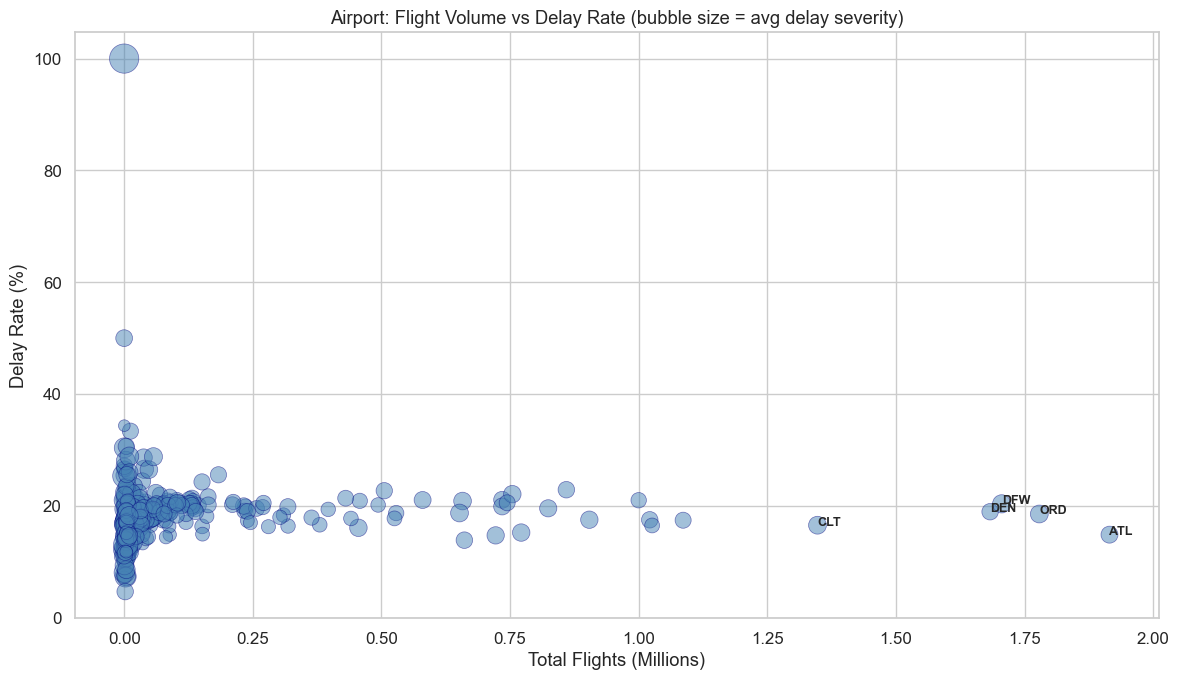

In [9]:
airport_perf = df.groupby('airport').agg(
    total_flights=('total_flights', 'sum'),
    delayed_flights=('delayed_flights', 'sum'),
    total_delay_min=('total_delay_minutes', 'sum')
).reset_index()
airport_perf['delay_rate'] = airport_perf['delayed_flights'] / airport_perf['total_flights']
airport_perf['avg_delay_min'] = airport_perf['total_delay_min'] / airport_perf['delayed_flights'].replace(0, 1)

# Scatter: volume vs delay rate
fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(
    airport_perf['total_flights'] / 1e6,
    airport_perf['delay_rate'] * 100,
    s=airport_perf['avg_delay_min'] * 2,
    alpha=0.5, c='steelblue', edgecolors='navy', linewidth=0.5
)
ax.set_xlabel('Total Flights (Millions)')
ax.set_ylabel('Delay Rate (%)')
ax.set_title('Airport: Flight Volume vs Delay Rate (bubble size = avg delay severity)')

# Label top outliers
for _, row in airport_perf.nlargest(5, 'total_flights').iterrows():
    ax.annotate(row['airport'], (row['total_flights']/1e6, row['delay_rate']*100), fontsize=9, fontweight='bold')
for _, row in airport_perf.nlargest(5, 'delay_rate').iterrows():
    if row['total_flights'] > 50000:  # only label airports with meaningful traffic
        ax.annotate(row['airport'], (row['total_flights']/1e6, row['delay_rate']*100), fontsize=9, color='red')

plt.tight_layout()
plt.show()

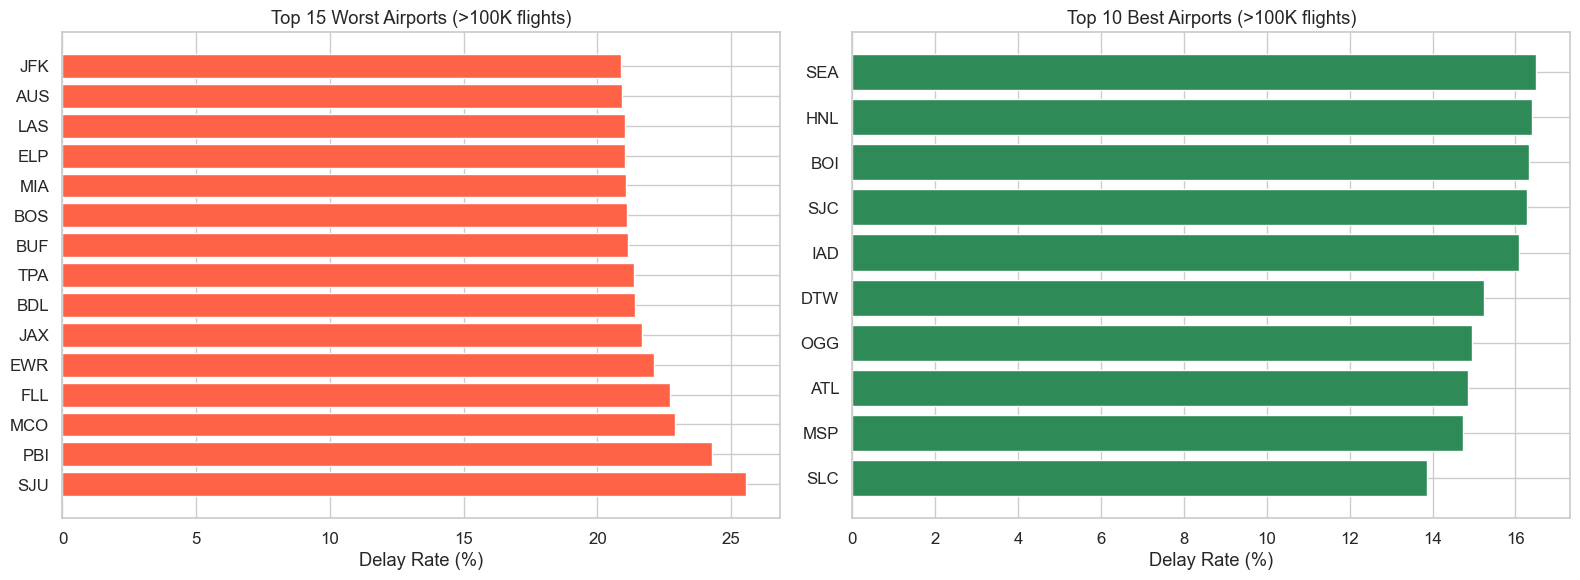

In [10]:
# Top 15 worst airports by delay rate (minimum 100k flights for statistical relevance)
high_traffic = airport_perf[airport_perf['total_flights'] > 100000]
worst_airports = high_traffic.nlargest(15, 'delay_rate')
best_airports = high_traffic.nsmallest(10, 'delay_rate')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(worst_airports['airport'], worst_airports['delay_rate']*100, color='tomato')
axes[0].set_xlabel('Delay Rate (%)')
axes[0].set_title('Top 15 Worst Airports (>100K flights)')

axes[1].barh(best_airports['airport'], best_airports['delay_rate']*100, color='seagreen')
axes[1].set_xlabel('Delay Rate (%)')
axes[1].set_title('Top 10 Best Airports (>100K flights)')

plt.tight_layout()
plt.show()


## Delay Cause Profiles by Airline
Do different airlines suffer from different types of delays? This reveals operational vs external issues.

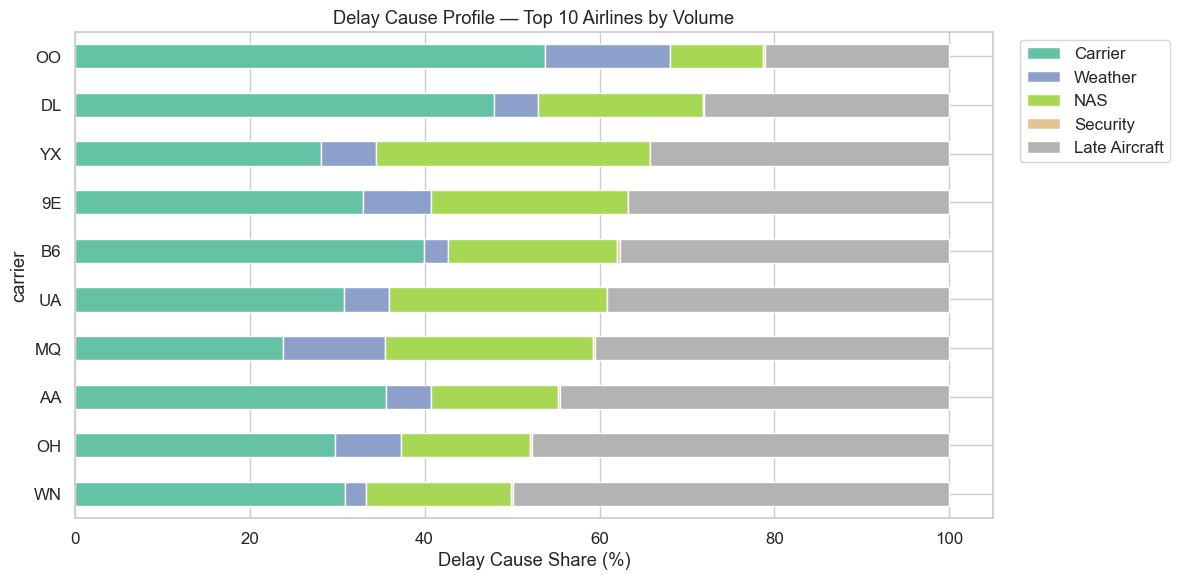


Insight: Airlines with highest Late Aircraft delay share (cascading delay problem):
  WN: 49.9%
  OH: 47.7%
  AA: 44.5%


In [11]:
# Top 10 airlines by volume
top10_carriers = df.groupby('carrier')['total_flights'].sum().nlargest(10).index
carrier_causes = df[df['carrier'].isin(top10_carriers)].groupby('carrier')[delay_cols].sum()

# Normalize
carrier_causes_pct = carrier_causes.div(carrier_causes.sum(axis=1), axis=0) * 100
carrier_causes_pct.columns = ['Carrier', 'Weather', 'NAS', 'Security', 'Late Aircraft']
carrier_causes_pct = carrier_causes_pct.sort_values('Late Aircraft', ascending=False)

carrier_causes_pct.plot(kind='barh', stacked=True, figsize=(12, 6), colormap='Set2')
plt.xlabel('Delay Cause Share (%)')
plt.title('Delay Cause Profile — Top 10 Airlines by Volume')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('\nInsight: Airlines with highest Late Aircraft delay share (cascading delay problem):')
for carrier in carrier_causes_pct.head(3).index:
    print(f'  {carrier}: {carrier_causes_pct.loc[carrier, "Late Aircraft"]:.1f}%')


## Correlation Analysis
How do delay causes relate to each other? Are certain delay types linked?

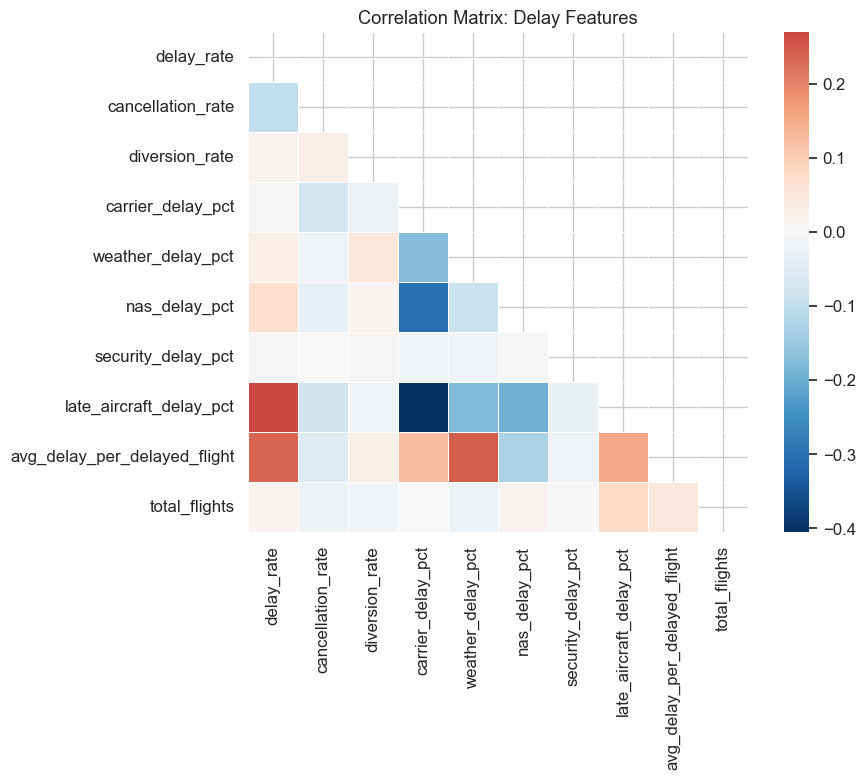

In [12]:
corr_cols = ['delay_rate', 'cancellation_rate', 'diversion_rate',
             'carrier_delay_pct', 'weather_delay_pct', 'nas_delay_pct',
             'security_delay_pct', 'late_aircraft_delay_pct',
             'avg_delay_per_delayed_flight', 'total_flights']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix: Delay Features')
plt.tight_layout()
plt.show()


## Year-over-Year Delay Cause Shift
Have the root causes of delays changed over the years? (e.g., weather getting worse, carrier issues improving)

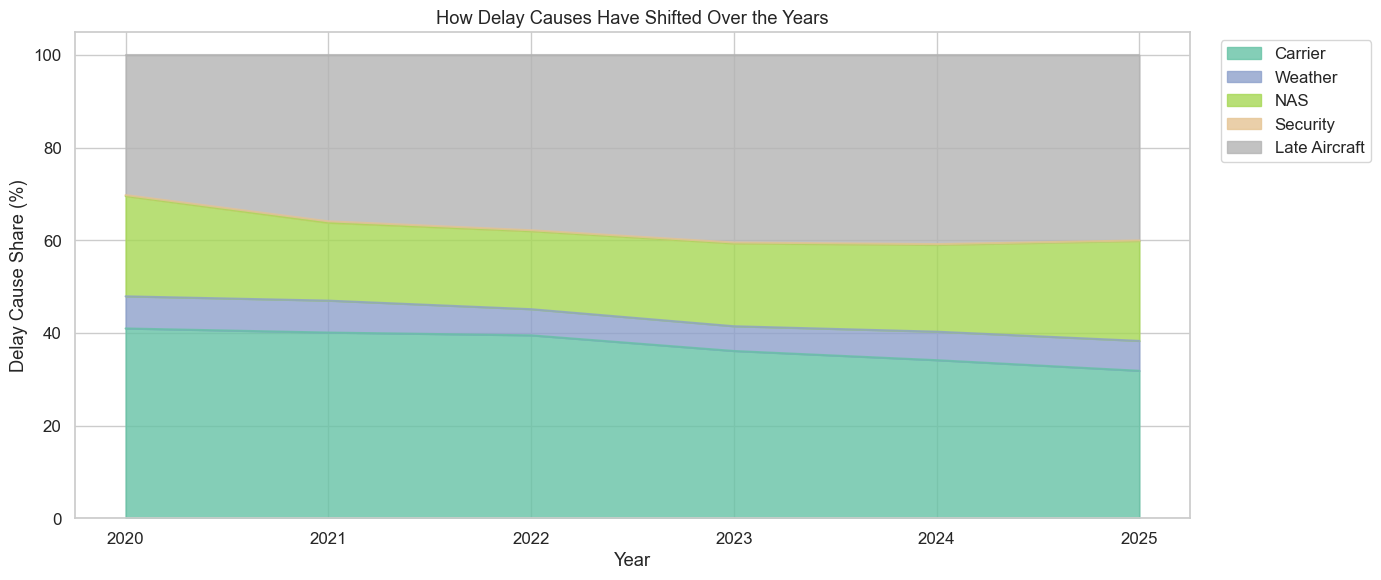

In [13]:
yearly_causes = df.groupby('year')[delay_cols].sum()
yearly_causes_pct = yearly_causes.div(yearly_causes.sum(axis=1), axis=0) * 100
yearly_causes_pct.columns = ['Carrier', 'Weather', 'NAS', 'Security', 'Late Aircraft']

yearly_causes_pct.plot(kind='area', stacked=True, figsize=(14, 6), colormap='Set2', alpha=0.8)
plt.xlabel('Year')
plt.ylabel('Delay Cause Share (%)')
plt.title('How Delay Causes Have Shifted Over the Years')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Dominant Delay Cause Distribution
For each airport-carrier-month record, what is the single biggest delay driver?

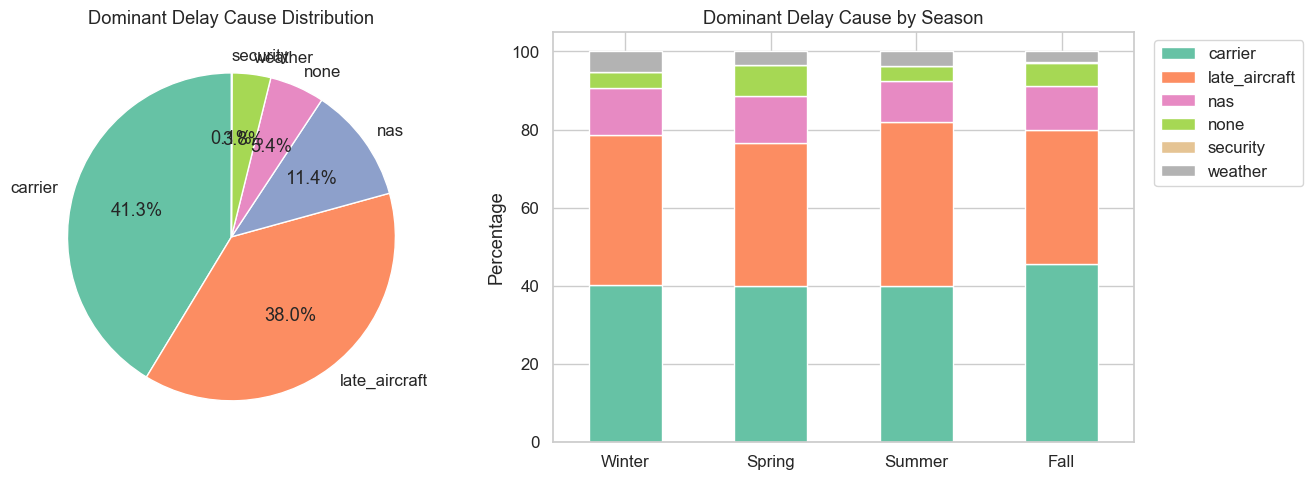

In [14]:
cause_dist = df['dominant_delay_cause'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(cause_dist, labels=cause_dist.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2'))
axes[0].set_title('Dominant Delay Cause Distribution')

# By season
cross = pd.crosstab(df['season'], df['dominant_delay_cause'], normalize='index') * 100
cross = cross.loc[season_order]
cross.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2')
axes[1].set_title('Dominant Delay Cause by Season')
axes[1].set_ylabel('Percentage')
axes[1].set_xlabel('')
axes[1].set_xticklabels(season_order, rotation=0)
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()


## High-Delay Route Identification
Which airport-airline combinations consistently have the worst performance?

In [15]:
route_perf = df.groupby(['airport', 'carrier']).agg(
    total_flights=('total_flights', 'sum'),
    delayed_flights=('delayed_flights', 'sum'),
    total_delay_min=('total_delay_minutes', 'sum')
).reset_index()
route_perf['delay_rate'] = route_perf['delayed_flights'] / route_perf['total_flights']

# Filter to routes with meaningful traffic
route_sig = route_perf[route_perf['total_flights'] > 10000]

print(f'Routes with >10K flights: {len(route_sig)}')
print('\nTop 15 worst airport-airline combos by delay rate:')
route_sig.nlargest(15, 'delay_rate')[['airport', 'carrier', 'total_flights', 'delay_rate']].reset_index(drop=True)

Routes with >10K flights: 600

Top 15 worst airport-airline combos by delay rate:


,airport,carrier,total_flights,delay_rate
0,ATL,F9,53561.0,0.327944
1,SJU,F9,23016.0,0.323471
2,FLL,G4,19545.0,0.323356
3,BWI,F9,11278.0,0.310959
4,SFO,F9,16758.0,0.308688
5,DFW,F9,33088.0,0.304068
6,EWR,B6,45112.0,0.302536
7,PHL,F9,50151.0,0.302387
8,ORD,F9,12623.0,0.302305
9,MIA,B6,13280.0,0.300527


In [18]:
print('KEY FINDINGS FROM EXPLORATORY DATA ANALYSIS')

# Overall
print(f'\n1. OVERALL: {total_delayed/total_flights*100:.1f}% of all flights are delayed >15 min')

# Worst month
worst_m = monthly_avg.loc[monthly_avg.avg_delay_rate.idxmax()]
best_m = monthly_avg.loc[monthly_avg.avg_delay_rate.idxmin()]
print(f'\n2. SEASONALITY: Month {int(worst_m["month"])} has the highest avg delay rate ({worst_m["avg_delay_rate"]*100:.1f}%),'
      f' Month {int(best_m["month"])} the lowest ({best_m["avg_delay_rate"]*100:.1f}%)')

# Top cause
top_cause = cause_totals.idxmax()
print(f'\n3. ROOT CAUSE: "{top_cause}" is the #1 delay driver ({cause_pct[top_cause]:.1f}% of all delay minutes)')

# Airline spread
print(f'\n4. AIRLINE SPREAD: Delay rates range from {top_airlines.delay_rate.min()*100:.1f}% to {top_airlines.delay_rate.max()*100:.1f}%'
      f' among top 15 airlines')

# Airport
print(f'\n5. AIRPORT: {len(high_traffic)} airports have >100K flights.')
print(f'   Worst: {worst_airports.iloc[0]["airport"]} ({worst_airports.iloc[0]["delay_rate"]*100:.1f}%)')
print(f'   Best:  {best_airports.iloc[0]["airport"]} ({best_airports.iloc[0]["delay_rate"]*100:.1f}%)')

KEY FINDINGS FROM EXPLORATORY DATA ANALYSIS

1. OVERALL: 18.7% of all flights are delayed >15 min

2. SEASONALITY: Month 7 has the highest avg delay rate (24.0%), Month 9 the lowest (14.6%)

3. ROOT CAUSE: "Late Aircraft" is the #1 delay driver (38.8% of all delay minutes)

4. AIRLINE SPREAD: Delay rates range from 13.7% to 26.3% among top 15 airlines

5. AIRPORT: 75 airports have >100K flights.
   Worst: SJU (25.6%)
   Best:  SLC (13.9%)
